In [1]:
import sys
sys.path.append('../')
from utils_models import *

In [2]:
with open('../pickles/EJ3_leak_test_decay.pkl', 'rb') as file:
    r0 = pickle.load(file)

In [3]:
results_leak = [r0[0]]

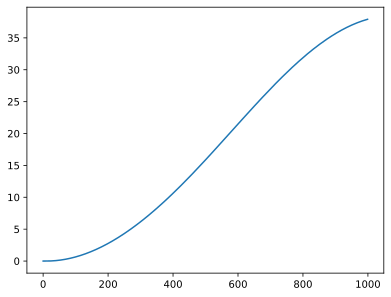

In [4]:
for result in results_leak:
    plt.plot(result.expect[1])

In [6]:

tlist = results_leak[0].times

prefix = rf'$\kappa = 10^{{-3}}$'
first_dominant_freq =find_dominant_frequency(results_leak[0].expect[0],tlist)

first_dominant_freq

-0.4685309999999999

In [7]:
first_dominant_freq = -0.46866

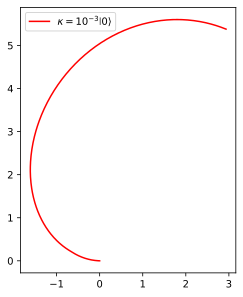

In [9]:

colors = ['red','blue','green']
for i, result in enumerate([results_leak[0]]):
    alpha = result.expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    # alpha = alpha[:550]
    plt.plot(alpha.imag,alpha.real,color=colors[i],label = prefix + rf'$\left|{i}\right>$')
plt.legend()
plt.gca().set_aspect('equal', 'box')

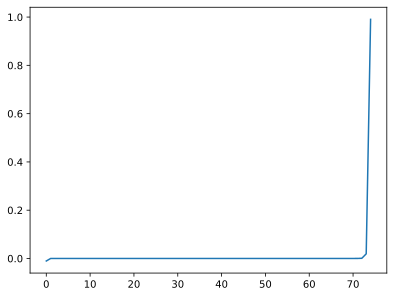

In [18]:
# rho_product = get_product(results_leak[1].states_pad_back_custom[400])
# rho = qutip.Qobj(np.array(rho_product.ptrace(1)))
# rho = rho/rho.tr()
# rho = rho_product.ptrace(1)
from qutip.sparse import eigh

values, vectors = eigh(results_leak[0].states[600].full())
plt.plot(values)